# Pure-space isotropic nugget-free Column Vecchia: resolution sensitivity by hour

This notebook removes the temporal covariance entirely and fits each time slot independently using a pure-space isotropic Column Vecchia model with nugget fixed at zero.

Resolution thinning:

- `x8`: keep regular-grid rows `0, 8, 16, ...`
- `x4`: keep `0, 4, 8, ...`
- `x2`: keep `0, 2, 4, ...`
- `x1`: keep all rows

Estimated full-fit parameters:

- `sigmasq`
- `range` (single isotropic spatial range)

Additional profile checks:

- `sigma_only_x1_anchor`: fix `range` at the same hour's full `x1` estimate, re-estimate only `sigmasq` at each resolution.
- `range_only_x1_anchor`: fix `sigmasq` at the same hour's full `x1` estimate, re-estimate only `range` at each resolution.

In [1]:
import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.kernels_space_iso_050826 import ColumnSpaceIsoNoNuggetTrendVecchiaFit

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
print('SRC:', SRC)
print('device:', DEVICE)

SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

RESOLUTION_STRIDES = [8, 4, 2, 1]
FIT_SMOOTHS = [0.5, 1.5]
MEAN_DESIGN = 'latlon'      # hourly pure-space: intercept + lat + lon detrending

COLUMN_SPEC = {
    'model': 'ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc',
    'head_right_cols': 0,
    'above_count': 2,
    'right_col_count': 3,
    'per_time_conditioning_count': 10,
    'target_chunk_size': 512,
}

LBFGS_LR = 1.0
LBFGS_STEPS_FULL = 8
LBFGS_STEPS_PARTIAL = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

INIT_ISO = {
    'sigmasq': 13.0,
    'range': 0.25,
}
P_LABELS = ['sigmasq', 'range']
P_IDX = {'sigmasq': 0, 'range': 1}

RUN_FULL = True
RUN_PARTIAL = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'real_pure_space_iso_nugget0_column_resolution_050826'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('column:', COLUMN_SPEC)
print('init:', INIT_ISO)

day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
column: {'model': 'ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc', 'head_right_cols': 0, 'above_count': 2, 'right_col_count': 3, 'per_time_conditioning_count': 10, 'target_chunk_size': 512}
init: {'sigmasq': 13.0, 'range': 0.25}


In [3]:
def phys_to_log_iso(d):
    return [np.log(d['sigmasq']), np.log(d['range'])]


def backmap_iso(raw):
    return {
        'sigmasq': float(np.exp(raw[0])),
        'range': float(np.exp(raw[1])),
        'nugget': 0.0,
    }


def make_full_params(init=INIT_ISO):
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log_iso(init)]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'

In [4]:
loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)
month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

print('monthly_mean:', round(monthly_mean, 4))
print('day keys:', day_keys[0], '...', day_keys[-1])
print('full grid:', grid_coords_full.shape)
print('unique lat/lon:', len(np.unique(np.round(grid_coords_full[:,0], 6))), len(np.unique(np.round(grid_coords_full[:,1], 6))))

--- Global Monthly Mean for 2024-7: 257.9726 ---
monthly_mean: 257.9726
day keys: 2024_07_y24m07day03_hm00:53 ... 2024_07_y24m07day03_hm07:48
full grid: (18126, 2)
unique lat/lon: 114 159


In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in hour_map.items()}, key


def thin_hour_map(hour_map, stride):
    n_full = grid_coords_full.shape[0]
    thin_idx = np.arange(0, n_full, int(stride), dtype=np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def build_model(input_map, grid_coords, smooth):
    return ColumnSpaceIsoNoNuggetTrendVecchiaFit(
        smooth=smooth,
        input_map=input_map,
        grid_coords=grid_coords,
        head_right_cols=COLUMN_SPEC['head_right_cols'],
        above_count=COLUMN_SPEC['above_count'],
        right_col_count=COLUMN_SPEC['right_col_count'],
        per_time_conditioning_count=COLUMN_SPEC['per_time_conditioning_count'],
        target_chunk_size=COLUMN_SPEC['target_chunk_size'],
        mean_design=MEAN_DESIGN,
    )


def make_base_row(hour_idx, time_key, stride, smooth, fit_type, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag):
    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'smooth': float(smooth),
        'mean_design': MEAN_DESIGN,
        'fit_type': fit_type,
        'model': COLUMN_SPEC['model'],
        'kernel': 'column_space_iso_nugget0_tonly_realloc',
        'coord_mode': 'regular-grid every-k thinning; covariance on Source_Latitude/Source_Longitude',
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        **{f'est_{p}': est[p] for p in P_LABELS},
        'est_nugget': 0.0,
        **diag,
        'total_conditioning_nominal': COLUMN_SPEC['per_time_conditioning_count'],
        'head_right_cols': COLUMN_SPEC['head_right_cols'],
        'above_count': COLUMN_SPEC['above_count'],
        'right_col_count': COLUMN_SPEC['right_col_count'],
        'per_time_conditioning_count': COLUMN_SPEC['per_time_conditioning_count'],
    }
    return row

In [6]:
def fit_full_iso(hour_idx, stride, smooth):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, _ = thin_hour_map(hour_map, stride)
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 90)
    print(f'FULL ISO | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(thin_map, thin_grid, smooth)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_full_params()
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_FULL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    est = backmap_iso(out[:2])
    row = make_base_row(hour_idx, time_key, stride, smooth, 'full', n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['resolution_label','loss','est_sigmasq','est_range','est_nugget','total_s']})

    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row


def fit_partial_iso(hour_idx, stride, smooth, anchor, fit_type):
    if fit_type == 'sigma_only_x1_anchor':
        free_name = 'sigmasq'
        fixed_names = ['range']
    elif fit_type == 'range_only_x1_anchor':
        free_name = 'range'
        fixed_names = ['sigmasq']
    else:
        raise ValueError(f'unknown fit_type={fit_type}')

    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, _ = thin_hour_map(hour_map, stride)
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 90)
    print(f'{fit_type} | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | anchor=x1, nugget=0')

    model = build_model(thin_map, thin_grid, smooth)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    fixed_log = {p: torch.tensor(np.log(anchor[p]), device=DEVICE, dtype=DTYPE) for p in P_LABELS}
    free_param = torch.tensor([np.log(anchor[free_name])], device=DEVICE, dtype=DTYPE, requires_grad=True)
    opt = model.set_optimizer([free_param], lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)

    def assemble_params():
        pieces = []
        for p in P_LABELS:
            if p == free_name:
                pieces.append(free_param.reshape(()))
            else:
                pieces.append(fixed_log[p].reshape(()))
        return torch.stack(pieces)

    print('--- Starting partial Pure-Space Iso L-BFGS ---')
    t_fit = time.time()
    last_iter = 0
    loss = None
    for i in range(LBFGS_STEPS_PARTIAL):
        last_iter = i
        def closure():
            opt.zero_grad()
            l = model.vecchia_batched_likelihood(assemble_params())
            l.backward()
            return l
        loss = opt.step(closure)
        grad = abs(float(free_param.grad.detach().item())) if free_param.grad is not None else 0.0
        print(f'--- Step {i + 1}/{LBFGS_STEPS_PARTIAL} / Loss: {float(loss.detach().item()):.6f} / {free_name} Grad: {grad:.2e} ---')
        if grad < GRAD_TOL:
            break
    fit_s = time.time() - t_fit

    final_log = [float(x.detach().cpu().item()) for x in assemble_params()]
    est = backmap_iso(final_log)
    row = make_base_row(hour_idx, time_key, stride, smooth, fit_type, n_grid, n_valid, pre_s, fit_s, float(loss.detach().cpu().item()), last_iter, est, diag)
    row.update({
        'free_parameter': free_name,
        'fixed_parameters': ','.join(fixed_names),
        'anchor_resolution_label': 'x1',
        **{f'anchor_{p}': anchor[p] for p in P_LABELS},
    })
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['resolution_label','loss','est_sigmasq','est_range','est_nugget','total_s']})

    del model, opt, free_param, hour_map, thin_map
    empty_cache()
    return row

In [7]:
full_rows = []
if RUN_FULL:
    for smooth in FIT_SMOOTHS:
        for hour_idx in HOUR_IDX_LIST:
            for stride in RESOLUTION_STRIDES:
                full_rows.append(fit_full_iso(hour_idx, stride, smooth))
                full_df_tmp = round_df(pd.DataFrame(full_rows))
                full_df_tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

full_df = pd.DataFrame(full_rows)
full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
round_df(full_df).to_csv(full_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved full fits:', full_path)
display(round_df(full_df))


FULL ISO | hour=1 | 2024_07_y24m07day03_hm00:53 | x8 | n_grid=2,266 | n_valid=2,259
Pre-computing ColumnSpaceVecchia [head_right=0, above=2, right_cols=3, m=10]... Done in 0.0s. grid=57x159, heads=0, tails=2259, m mean/med/max=8.7/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.644923 / Max Grad: 1.06e-07 ---
Converged: max_grad 1.06e-07 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 13.085768510864943, 'range': 0.17247738590378525, 'nugget': 0.0}
RESULT: {'resolution_label': 'x8', 'loss': 1.6449, 'total_s': 0.1343, 'est_sigmasq': 13.0858, 'est_range': 0.1725, 'est_nugget': 0.0}

FULL ISO | hour=1 | 2024_07_y24m07day03_hm00:53 | x4 | n_grid=4,532 | n_valid=4,518
Pre-computing ColumnSpaceVecchia [head_right=0, above=2, right_cols=3, m=10]... Done in 0.1s. grid=57x159, heads=0, tails=4518, m mean/med/max=9.5/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.518459 / Max Grad: 2.18e-06 ---
Converged: max_grad 2.18e-06 < 1.00e-05
Final Pure-S

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,smooth,mean_design,fit_type,model,kernel,coord_mode,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq,est_range,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n,total_conditioning_nominal,head_right_cols,above_count,right_col_count,per_time_conditioning_count
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,0.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.6449,0,1,0.0368,0.0975,0.1343,2266,2259,0.9969,13.0858,0.1725,0.0,1,2259,10.0,10,2259,10,0,2,3,10
1,20240703,2,0,2024_07_y24m07day03_hm00:53,4,x4,0.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.5185,0,1,0.0852,0.1867,0.2719,4532,4518,0.9969,11.8034,0.1691,0.0,1,4518,10.0,10,4518,10,0,2,3,10
2,20240703,2,0,2024_07_y24m07day03_hm00:53,2,x2,0.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.7648,0,1,0.2271,0.4344,0.6615,9063,9033,0.9967,13.5325,0.1067,0.0,1,9033,10.0,10,9033,10,0,2,3,10
3,20240703,2,0,2024_07_y24m07day03_hm00:53,1,x1,0.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.6803,0,1,0.7855,0.9172,1.7027,18126,18067,0.9967,12.3390,0.0932,0.0,1,18067,10.0,10,18067,10,0,2,3,10
4,20240703,2,1,2024_07_y24m07day03_hm01:53,8,x8,0.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.6844,0,1,0.0342,0.0812,0.1154,2266,2208,0.9744,14.9917,0.1964,0.0,1,2208,10.0,10,2208,10,0,2,3,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,20240703,2,6,2024_07_y24m07day03_hm06:48,1,x1,1.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,79.1616,0,1,0.8012,1.8566,2.6578,18126,18104,0.9988,12.5970,0.0337,0.0,1,18104,10.0,10,18104,10,0,2,3,10
60,20240703,2,7,2024_07_y24m07day03_hm07:48,8,x8,1.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,12.9082,0,1,0.0357,0.1490,0.1848,2266,2263,0.9987,14.7854,0.0532,0.0,1,2263,10.0,10,2263,10,0,2,3,10
61,20240703,2,7,2024_07_y24m07day03_hm07:48,4,x4,1.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,12.6540,0,1,0.0853,0.3924,0.4777,4532,4526,0.9987,13.3527,0.0581,0.0,1,4526,10.0,10,4526,10,0,2,3,10
62,20240703,2,7,2024_07_y24m07day03_hm07:48,2,x2,1.5,latlon,full,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,33.6469,0,1,0.2260,0.9804,1.2064,9063,9051,0.9987,12.4986,0.0414,0.0,1,9051,10.0,10,9051,10,0,2,3,10


In [8]:
partial_rows = []
if RUN_PARTIAL:
    if 'full_df' not in globals() or full_df.empty:
        full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
        full_df = pd.read_csv(full_path)

    anchor_rows = full_df[full_df['resolution_stride'] == 1].copy()
    anchors = {
        (int(r.hour_idx), float(r.smooth)): {
            'sigmasq': float(r.est_sigmasq),
            'range': float(r.est_range),
            'nugget': float(r.est_nugget),
        }
        for r in anchor_rows.itertuples(index=False)
    }
    print('anchors from x1 full fits:', anchors)

    for smooth in FIT_SMOOTHS:
        for hour_idx in HOUR_IDX_LIST:
            anchor = anchors[(int(hour_idx), float(smooth))]
            for fit_type in ['sigma_only_x1_anchor', 'range_only_x1_anchor']:
                for stride in RESOLUTION_STRIDES:
                    partial_rows.append(fit_partial_iso(hour_idx, stride, smooth, anchor, fit_type))
                    partial_df_tmp = round_df(pd.DataFrame(partial_rows))
                    partial_df_tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_partial.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

partial_df = pd.DataFrame(partial_rows)
partial_path = OUT_DIR / f'{OUT_PREFIX}_partial.csv'
round_df(partial_df).to_csv(partial_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved partial fits:', partial_path)
display(round_df(partial_df))

anchors from x1 full fits: {(0, 0.5): {'sigmasq': 12.339035923756088, 'range': 0.09324971686793837, 'nugget': 0.0}, (1, 0.5): {'sigmasq': 13.027881657103839, 'range': 0.11694020970905959, 'nugget': 0.0}, (2, 0.5): {'sigmasq': 14.981896628103543, 'range': 0.1401598688011228, 'nugget': 0.0}, (3, 0.5): {'sigmasq': 16.553123800317234, 'range': 0.1490780017875207, 'nugget': 0.0}, (4, 0.5): {'sigmasq': 17.046475312776717, 'range': 0.14102239118184193, 'nugget': 0.0}, (5, 0.5): {'sigmasq': 15.569909355078748, 'range': 0.126515472296331, 'nugget': 0.0}, (6, 0.5): {'sigmasq': 13.697851216806248, 'range': 0.11987738606146207, 'nugget': 0.0}, (7, 0.5): {'sigmasq': 12.921634579617088, 'range': 0.10590864679065969, 'nugget': 0.0}, (0, 1.5): {'sigmasq': 11.890960740412106, 'range': 0.029209461424221664, 'nugget': 0.0}, (1, 1.5): {'sigmasq': 12.167301261823486, 'range': 0.032590033625918446, 'nugget': 0.0}, (2, 1.5): {'sigmasq': 13.36673809751567, 'range': 0.03523503686955629, 'nugget': 0.0}, (3, 1.5

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,smooth,mean_design,fit_type,model,kernel,coord_mode,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq,est_range,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n,total_conditioning_nominal,head_right_cols,above_count,right_col_count,per_time_conditioning_count,free_parameter,fixed_parameters,anchor_resolution_label,anchor_sigmasq,anchor_range
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,0.5,latlon,sigma_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.6564,0,1,0.0352,0.0594,0.0946,2266,2259,0.9969,11.1282,0.0932,0.0,1,2259,10.0,10,2259,10,0,2,3,10,sigmasq,range,x1,12.3390,0.0932
1,20240703,2,0,2024_07_y24m07day03_hm00:53,4,x4,0.5,latlon,sigma_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.5410,7,8,0.0869,0.3290,0.4160,4532,4518,0.9969,9.3358,0.0932,0.0,1,4518,10.0,10,4518,10,0,2,3,10,sigmasq,range,x1,12.3390,0.0932
2,20240703,2,0,2024_07_y24m07day03_hm00:53,2,x2,0.5,latlon,sigma_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.5571,0,1,0.2245,0.1214,0.3459,9063,9033,0.9967,12.4199,0.0932,0.0,1,9033,10.0,10,9033,10,0,2,3,10,sigmasq,range,x1,12.3390,0.0932
3,20240703,2,0,2024_07_y24m07day03_hm00:53,1,x1,0.5,latlon,sigma_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.4306,0,1,0.7956,0.0860,0.8816,18126,18067,0.9967,12.3390,0.0932,0.0,1,18067,10.0,10,18067,10,0,2,3,10,sigmasq,range,x1,12.3390,0.0932
4,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,0.5,latlon,range_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.6564,0,1,0.0356,0.0733,0.1089,2266,2259,0.9969,12.3390,0.1640,0.0,1,2259,10.0,10,2259,10,0,2,3,10,range,sigmasq,x1,12.3390,0.0932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,20240703,2,7,2024_07_y24m07day03_hm07:48,1,x1,1.5,latlon,sigma_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.4518,0,1,0.7808,0.0785,0.8593,18126,18102,0.9987,12.1856,0.0318,0.0,1,18102,10.0,10,18102,10,0,2,3,10,sigmasq,range,x1,12.1856,0.0318
124,20240703,2,7,2024_07_y24m07day03_hm07:48,8,x8,1.5,latlon,range_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.7668,7,8,0.0362,0.1376,0.1738,2266,2263,0.9987,12.1856,0.0496,0.0,1,2263,10.0,10,2263,10,0,2,3,10,range,sigmasq,x1,12.1856,0.0318
125,20240703,2,7,2024_07_y24m07day03_hm07:48,4,x4,1.5,latlon,range_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.6419,7,8,0.0890,0.2833,0.3723,4532,4526,0.9987,12.1856,0.0561,0.0,1,4526,10.0,10,4526,10,0,2,3,10,range,sigmasq,x1,12.1856,0.0318
126,20240703,2,7,2024_07_y24m07day03_hm07:48,2,x2,1.5,latlon,range_only_x1_anchor,ColumnSpaceIsoNoNugget_Up2_Right3_M10_realloc,column_space_iso_nugget0_tonly_realloc,regular-grid every-k thinning; covariance on S...,1.5188,7,8,0.2354,0.5196,0.7550,9063,9051,0.9987,12.1856,0.0410,0.0,1,9051,10.0,10,9051,10,0,2,3,10,range,sigmasq,x1,12.1856,0.0318


In [9]:
all_df = pd.concat([full_df, partial_df], ignore_index=True, sort=False)
all_path = OUT_DIR / f'{OUT_PREFIX}_all.csv'
round_df(all_df).to_csv(all_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved all:', all_path)

param_rows = []
for _, row in all_df.iterrows():
    for p in P_LABELS:
        param_rows.append({
            'date_str': row['date_str'],
            'hour_idx': int(row['hour_idx']),
            'time_key': row['time_key'],
            'resolution_stride': int(row['resolution_stride']),
            'resolution_label': row['resolution_label'],
            'fit_type': row['fit_type'],
            'parameter': p,
            'estimate': row[f'est_{p}'],
            'loss': row['loss'],
            'n_grid': row['n_grid'],
            'n_valid': row['n_valid'],
        })
param_df = pd.DataFrame(param_rows)
param_path = OUT_DIR / f'{OUT_PREFIX}_param_table.csv'
round_df(param_df).to_csv(param_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved param table:', param_path)

display_cols = ['hour_idx', 'resolution_stride', 'resolution_label', 'fit_type', 'loss', 'est_sigmasq', 'est_range', 'est_nugget', 'n_grid', 'n_valid', 'total_s']
display(round_df(all_df[display_cols].sort_values(['fit_type', 'hour_idx', 'resolution_stride'])))

Saved all: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_iso_nugget0_column_resolution_050826_all.csv
Saved param table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_iso_nugget0_column_resolution_050826_param_table.csv


,hour_idx,resolution_stride,resolution_label,fit_type,loss,est_sigmasq,est_range,est_nugget,n_grid,n_valid,total_s
3,0,1,x1,full,1.6803,12.3390,0.0932,0.0,18126,18067,1.7027
35,0,1,x1,full,96.5691,11.8910,0.0292,0.0,18126,18067,2.2438
2,0,2,x2,full,1.7648,13.5325,0.1067,0.0,9063,9033,0.6615
34,0,2,x2,full,42.1475,13.0568,0.0371,0.0,9063,9033,0.8666
1,0,4,x4,full,1.5185,11.8034,0.1691,0.0,4532,4518,0.2719
...,...,...,...,...,...,...,...,...,...,...,...
186,7,2,x2,sigma_only_x1_anchor,1.5515,10.2760,0.0318,0.0,9063,9051,0.4602
121,7,4,x4,sigma_only_x1_anchor,1.6289,11.6603,0.1059,0.0,4532,4526,0.1855
185,7,4,x4,sigma_only_x1_anchor,1.7387,12.2578,0.0318,0.0,4532,4526,0.1543
120,7,8,x8,sigma_only_x1_anchor,1.7470,13.8475,0.1059,0.0,2266,2263,0.0785


Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_iso_nugget0_column_resolution_050826_smooth0p5_full_parameter_trajectories.png


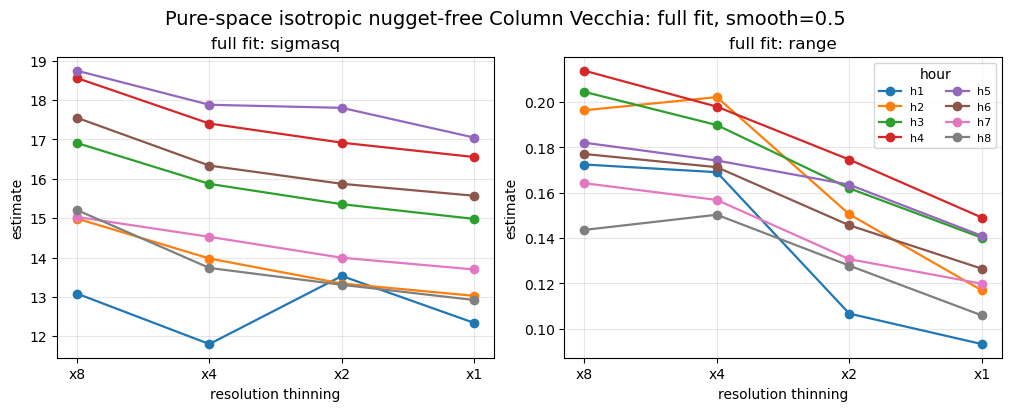

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_iso_nugget0_column_resolution_050826_smooth1p5_full_parameter_trajectories.png


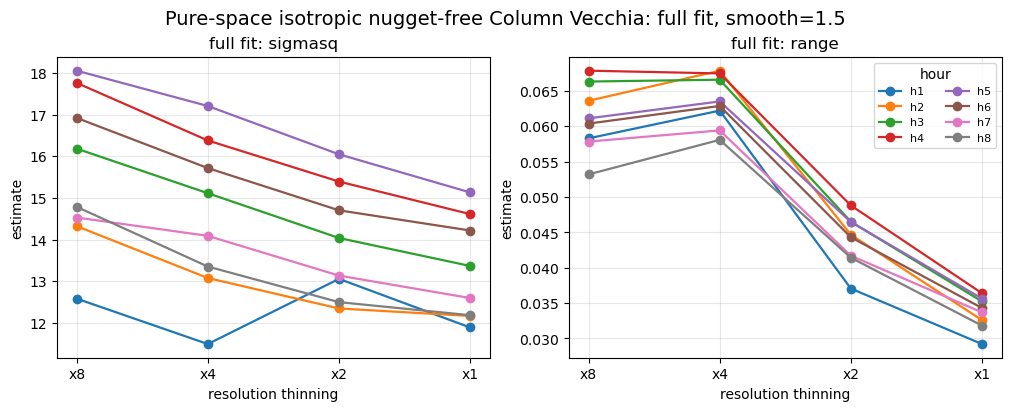

In [10]:
# Full-fit parameter trajectories: one line per hour, saved separately by smooth.
plot_full = full_df.copy()
plot_full['resolution_label'] = pd.Categorical(
    plot_full['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_full = plot_full.sort_values(['smooth', 'hour_idx', 'resolution_label'])

for smooth, plot_s in plot_full.groupby('smooth'):
    fig, axes = plt.subplots(1, len(P_LABELS), figsize=(5 * len(P_LABELS), 4), constrained_layout=True)
    axes = np.atleast_1d(axes)
    for ax, p in zip(axes, P_LABELS):
        for hour_idx, sub in plot_s.groupby('hour_idx'):
            ax.plot(sub['resolution_label'].astype(str), sub[f'est_{p}'], marker='o', linewidth=1.6, label=f'h{int(hour_idx)+1}')
        ax.set_title(f'full fit: {p}')
        ax.set_xlabel('resolution thinning')
        ax.set_ylabel('estimate')
        ax.grid(True, alpha=0.3)
    axes[-1].legend(ncol=2, fontsize=8, title='hour')
    fig.suptitle(f'Pure-space isotropic nugget-free Column Vecchia: full fit, smooth={smooth}', fontsize=14)
    smooth_tag = str(smooth).replace('.', 'p')
    full_plot_path = OUT_DIR / f'{OUT_PREFIX}_smooth{smooth_tag}_full_parameter_trajectories.png'
    fig.savefig(full_plot_path, dpi=180, bbox_inches='tight')
    print('Saved:', full_plot_path)
    plt.show()

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_iso_nugget0_column_resolution_050826_smooth0p5_partial_parameter_trajectories.png


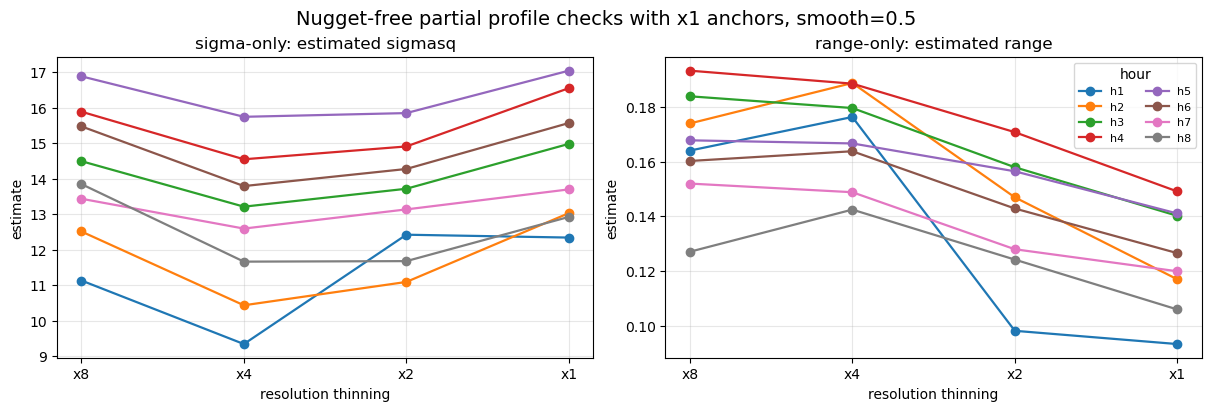

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_iso_nugget0_column_resolution_050826_smooth1p5_partial_parameter_trajectories.png


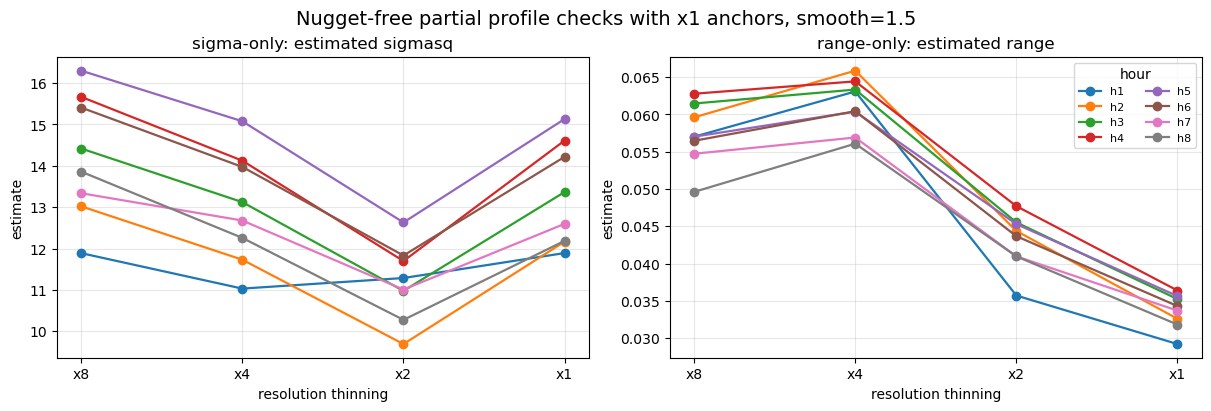

In [11]:
# Partial-fit trajectories: sigma-only and range-only using x1 full-fit anchor, saved separately by smooth.
if not partial_df.empty:
    plot_partial = partial_df.copy()
    plot_partial['resolution_label'] = pd.Categorical(
        plot_partial['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
    )
    plot_partial = plot_partial.sort_values(['smooth', 'fit_type', 'hour_idx', 'resolution_label'])

    specs = [
        ('sigma_only_x1_anchor', 'sigmasq', 'sigma-only: estimated sigmasq'),
        ('range_only_x1_anchor', 'range', 'range-only: estimated range'),
    ]
    for smooth, plot_s in plot_partial.groupby('smooth'):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
        for ax, (fit_type, p, title) in zip(axes, specs):
            sub0 = plot_s[plot_s['fit_type'] == fit_type]
            for hour_idx, sub in sub0.groupby('hour_idx'):
                ax.plot(sub['resolution_label'].astype(str), sub[f'est_{p}'], marker='o', linewidth=1.6, label=f'h{int(hour_idx)+1}')
            ax.set_title(title)
            ax.set_xlabel('resolution thinning')
            ax.set_ylabel('estimate')
            ax.grid(True, alpha=0.3)
        axes[-1].legend(ncol=2, fontsize=8, title='hour')
        fig.suptitle(f'Nugget-free partial profile checks with x1 anchors, smooth={smooth}', fontsize=14)
        smooth_tag = str(smooth).replace('.', 'p')
        partial_plot_path = OUT_DIR / f'{OUT_PREFIX}_smooth{smooth_tag}_partial_parameter_trajectories.png'
        fig.savefig(partial_plot_path, dpi=180, bbox_inches='tight')
        print('Saved:', partial_plot_path)
        plt.show()